### Задание

1) Модифицируйте код и реализуйте [Wasserstein GAN](https://arxiv.org/abs/1701.07875) ([From GAN to WGAN
](https://lilianweng.github.io/posts/2017-08-20-gan/)) используя weight clipping. (1 балл)

2) Замените  weight clipping на [gradient penalty](https://arxiv.org/pdf/1704.00028v3.pdf). (1 балл)

3) Добавьте к обучению WGAN условие на метку, продемонстрируйте [условную генерацию](https://arxiv.org/pdf/1411.1784.pdf).  (2 балл)

4) Напишите отчет о том, что попробовали, какие результаты получили, какую архитектуру использовали, как вам кажется надо обучать GAN, чтобы добиться сходимости? Каждый пункт обязательно сопроводите визуализациями (1 балл)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import torchvision
import matplotlib.pyplot as plt
import numpy as np

from torch.autograd import Variable

In [4]:
device = torch.device("mps")

In [5]:
class Config:
    pass


config = Config()
config.mnist_path = None
config.batch_size = 16
config.num_workers = 3
config.num_epochs = 10
config.noise_size = 50
config.print_freq = 100

In [6]:
train = torchvision.datasets.FashionMNIST(
    "fashion_mnist", train=True, transform=torchvision.transforms.ToTensor(), download=True)

In [7]:
dataloader = DataLoader(train, batch_size=16, shuffle=True)

In [8]:
len(dataloader)

3750

In [9]:
for image, cat in dataloader:
    image

In [10]:
image.size()

torch.Size([16, 1, 28, 28])

In [11]:
28*28

784

In [12]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(config.noise_size, 200),
            nn.ReLU(inplace=True),
            nn.Linear(200, 28*28),
            nn.Sigmoid())

    def forward(self, x):
        return self.model(x)


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 200),
            nn.ReLU(inplace=True),
            nn.Linear(200, 50),
            nn.ReLU(inplace=True),
            nn.Linear(50, 1),
            nn.Sigmoid())

    def forward(self, x):
        return self.model(x)

In [13]:
generator = Generator()
discriminator = Discriminator()

In [14]:
optim_G = optim.Adam(params=generator.parameters(), lr=0.0001)
optim_D = optim.Adam(params=discriminator.parameters(), lr=0.0001)

criterion = nn.BCELoss()

In [15]:
noise = torch.FloatTensor(config.batch_size, config.noise_size)
label = torch.FloatTensor(config.batch_size, 1)
real_label = 1
fake_label = 0

ERRD_x = np.zeros(config.num_epochs)
ERRD_z = np.zeros(config.num_epochs)
ERRG = np.zeros(config.num_epochs)
N = len(dataloader)
for epoch in range(config.num_epochs):
    for iteration, (images, cat) in enumerate(dataloader):
        #######
        # Discriminator stage: maximize log(D(x)) + log(1 - D(G(z)))
        #######
        discriminator.zero_grad()

        # real
        label.fill_(real_label)
        input_data = images.view(images.shape[0], -1)
        output = discriminator(input_data)
        errD_x = criterion(output, label)
        ERRD_x[epoch] += errD_x.item()
        errD_x.backward()

        # fake
        noise.normal_(0, 1)
        fake = generator(noise)
        label.fill_(fake_label)
        output = discriminator(fake.detach())
        errD_z = criterion(output, label)
        ERRD_z[epoch] += errD_z.item()
        errD_z.backward()

        optim_D.step()

        #######
        # Generator stage: maximize log(D(G(x))
        #######
        generator.zero_grad()
        label.fill_(real_label)
        output = discriminator(fake)
        errG = criterion(output, label)
        ERRG[epoch] += errG.item()
        errG.backward()

        optim_G.step()

        if (iteration+1) % config.print_freq == 0:
            print('Epoch:{} Iter: {} errD_x: {:.2f} errD_z: {:.2f} errG: {:.2f}'.format(epoch+1,
                                                                                        iteration+1,
                                                                                        errD_x.item(),
                                                                                        errD_z.item(),
                                                                                        errG.item()))

Epoch:1 Iter: 100 errD_x: 0.28 errD_z: 0.13 errG: 2.21
Epoch:1 Iter: 200 errD_x: 0.28 errD_z: 0.23 errG: 1.94
Epoch:1 Iter: 300 errD_x: 0.25 errD_z: 0.18 errG: 2.06
Epoch:1 Iter: 400 errD_x: 0.16 errD_z: 0.09 errG: 2.66
Epoch:1 Iter: 500 errD_x: 0.29 errD_z: 0.09 errG: 2.42
Epoch:1 Iter: 600 errD_x: 0.29 errD_z: 0.07 errG: 2.89
Epoch:1 Iter: 700 errD_x: 0.10 errD_z: 0.13 errG: 2.39
Epoch:1 Iter: 800 errD_x: 0.32 errD_z: 0.07 errG: 2.94
Epoch:1 Iter: 900 errD_x: 0.27 errD_z: 0.15 errG: 2.31
Epoch:1 Iter: 1000 errD_x: 0.33 errD_z: 0.23 errG: 1.85
Epoch:1 Iter: 1100 errD_x: 0.32 errD_z: 0.10 errG: 2.43
Epoch:1 Iter: 1200 errD_x: 0.27 errD_z: 0.15 errG: 2.26
Epoch:1 Iter: 1300 errD_x: 0.10 errD_z: 0.25 errG: 1.84
Epoch:1 Iter: 1400 errD_x: 0.12 errD_z: 0.21 errG: 2.07
Epoch:1 Iter: 1500 errD_x: 0.14 errD_z: 0.28 errG: 1.83
Epoch:1 Iter: 1600 errD_x: 0.12 errD_z: 0.19 errG: 2.19
Epoch:1 Iter: 1700 errD_x: 0.21 errD_z: 0.27 errG: 1.89
Epoch:1 Iter: 1800 errD_x: 0.19 errD_z: 0.24 errG: 2.23
E

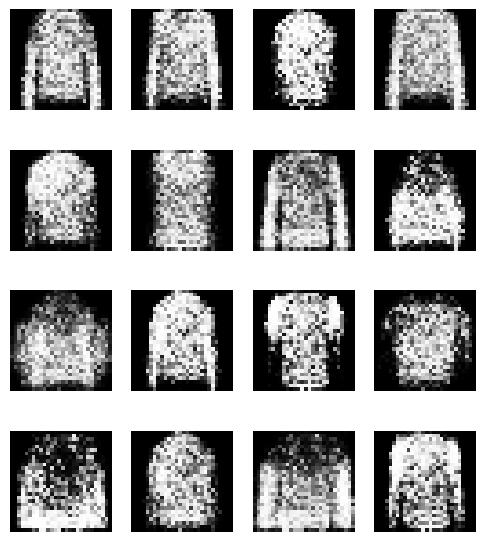

In [16]:
noise.normal_(0, 1)
fake = generator(noise)

plt.figure(figsize=(6, 7))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake[i].detach().numpy().reshape(28, 28), cmap=plt.cm.Greys_r)
    plt.axis('off')

In [17]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(config.noise_size, 200),
            nn.ReLU(inplace=True),
            nn.Linear(200, 28*28),
            nn.Tanh())

    def forward(self, x):
        return self.model(x)


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 200),
            nn.ReLU(inplace=True),
            nn.Linear(200, 50),
            nn.ReLU(inplace=True),
            nn.Linear(50, 1),)

    def forward(self, x):
        return self.model(x)


def critic_loss(real_scores, fake_scores):
    return -(torch.mean(real_scores) - torch.mean(fake_scores))

In [18]:
generator = Generator()
critic = Critic()

optim_C = optim.Adam(params=critic.parameters(), lr=0.0001)
optim_G = optim.Adam(params=generator.parameters(), lr=0.0001)

In [19]:
noise = torch.FloatTensor(config.batch_size, config.noise_size)

REAL_SCORES = np.zeros(config.num_epochs)
FAKE_SCORES_D = np.zeros(config.num_epochs)
FAKE_SCORES_G = np.zeros(config.num_epochs)
N = len(dataloader)

n_critic = 5
clip_value = 0.01

for epoch in range(config.num_epochs):
    for iteration, (images, cat) in enumerate(dataloader):

        for _ in range(n_critic):
            critic.zero_grad()

            input_data = images.view(images.shape[0], -1)
            real_scores = critic(input_data)

            noise.normal_(0, 1)
            fake = generator(noise)
            fake_scores = critic(fake.detach())

            loss_critic = -(torch.mean(real_scores) - torch.mean(fake_scores))
            loss_critic.backward()
            optim_C.step()

            for p in critic.parameters():
                p.data.clamp_(-clip_value, clip_value)

            REAL_SCORES[epoch] += real_scores.mean().item()
            FAKE_SCORES_D[epoch] += fake_scores.mean().item()

        generator.zero_grad()

        noise.normal_(0, 1)
        fake = generator(noise)
        fake_scores = critic(fake)

        loss_generator = -torch.mean(fake_scores)
        loss_generator.backward()
        optim_G.step()

        FAKE_SCORES_G[epoch] += fake_scores.mean().item()

        if (iteration+1) % config.print_freq == 0:
            current_real = REAL_SCORES[epoch] / (iteration + 1) / n_critic
            current_fake_d = FAKE_SCORES_D[epoch] / (iteration + 1) / n_critic
            current_fake_g = FAKE_SCORES_G[epoch] / (iteration + 1)

            wasserstein_dist = current_real - current_fake_d

            print('Epoch:{} Iter: {} D_real: {:.4f} D_fake: {:.4f} G: {:.4f} W_dist: {:.4f}'.format(
                epoch+1, iteration+1, current_real, current_fake_d, current_fake_g, wasserstein_dist))

REAL_SCORES /= (N * n_critic)
FAKE_SCORES_D /= (N * n_critic)
FAKE_SCORES_G /= N

Epoch:1 Iter: 100 D_real: 0.3996 D_fake: 0.1525 G: 0.1497 W_dist: 0.2471
Epoch:1 Iter: 200 D_real: 0.2661 D_fake: 0.0910 G: 0.0844 W_dist: 0.1752
Epoch:1 Iter: 300 D_real: 0.1941 D_fake: 0.0311 G: 0.0238 W_dist: 0.1630
Epoch:1 Iter: 400 D_real: 0.1655 D_fake: 0.0014 G: -0.0061 W_dist: 0.1641
Epoch:1 Iter: 500 D_real: 0.1454 D_fake: -0.0200 G: -0.0276 W_dist: 0.1654
Epoch:1 Iter: 600 D_real: 0.1325 D_fake: -0.0356 G: -0.0427 W_dist: 0.1681
Epoch:1 Iter: 700 D_real: 0.1237 D_fake: -0.0449 G: -0.0515 W_dist: 0.1686
Epoch:1 Iter: 800 D_real: 0.1195 D_fake: -0.0489 G: -0.0553 W_dist: 0.1684
Epoch:1 Iter: 900 D_real: 0.1171 D_fake: -0.0508 G: -0.0570 W_dist: 0.1678
Epoch:1 Iter: 1000 D_real: 0.1141 D_fake: -0.0534 G: -0.0596 W_dist: 0.1676
Epoch:1 Iter: 1100 D_real: 0.1143 D_fake: -0.0521 G: -0.0583 W_dist: 0.1664
Epoch:1 Iter: 1200 D_real: 0.1132 D_fake: -0.0518 G: -0.0580 W_dist: 0.1650
Epoch:1 Iter: 1300 D_real: 0.1118 D_fake: -0.0521 G: -0.0583 W_dist: 0.1638
Epoch:1 Iter: 1400 D_real: 0

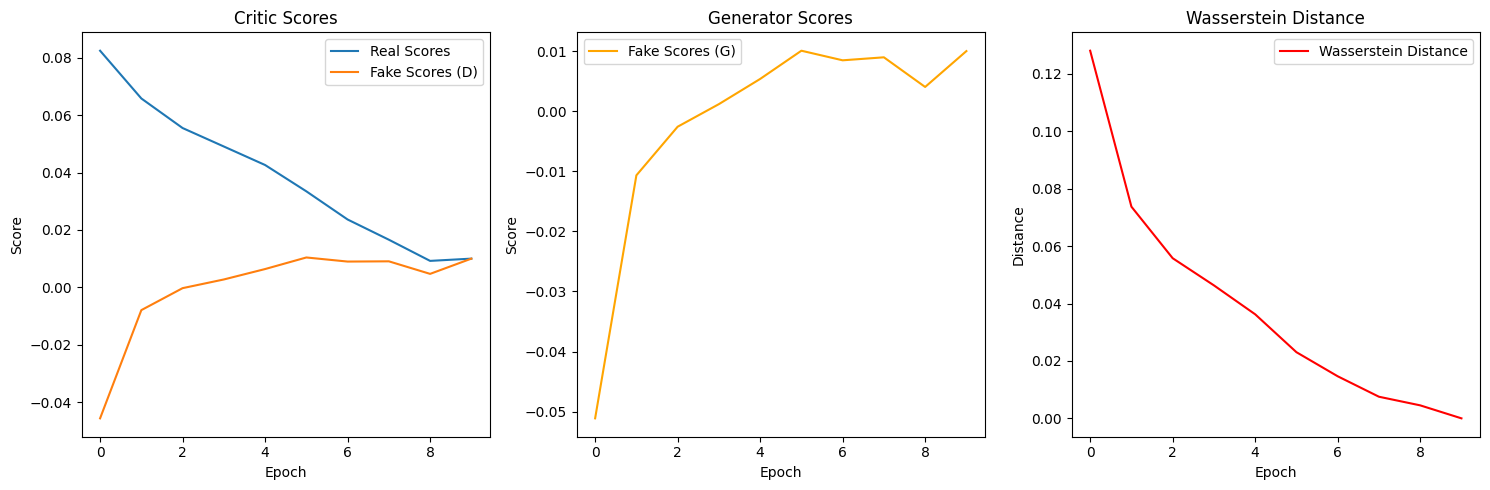

In [20]:
epochs = range(config.num_epochs)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, REAL_SCORES, label='Real Scores')
plt.plot(epochs, FAKE_SCORES_D, label='Fake Scores (D)')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Critic Scores')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, FAKE_SCORES_G, label='Fake Scores (G)', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Generator Scores')
plt.legend()

plt.subplot(1, 3, 3)
wasserstein_dist = REAL_SCORES - FAKE_SCORES_D
plt.plot(epochs, wasserstein_dist, label='Wasserstein Distance', color='red')
plt.xlabel('Epoch')
plt.ylabel('Distance')
plt.title('Wasserstein Distance')
plt.legend()

plt.tight_layout()
plt.show()

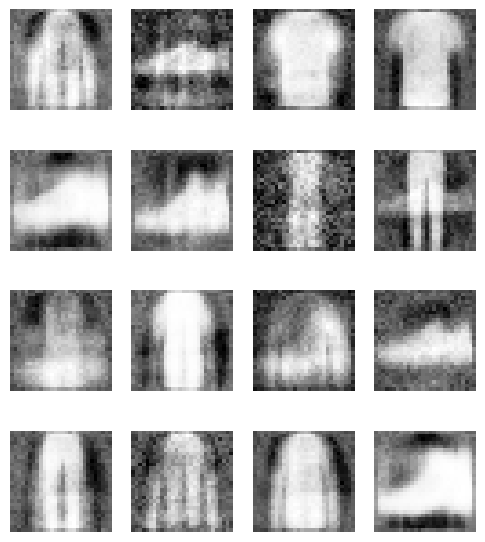

In [21]:
noise.normal_(0, 1)
fake = generator(noise)

plt.figure(figsize=(6, 7))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake[i].detach().numpy().reshape(28, 28), cmap=plt.cm.Greys_r)
    plt.axis('off')

In [22]:
generator = Generator().to(device)
critic = Critic().to(device)

optim_C = optim.Adam(params=critic.parameters(), lr=0.0001)
optim_G = optim.Adam(params=generator.parameters(), lr=0.0001)

In [23]:
def compute_gradient_penalty(critic, real_samples, fake_samples, device):
    batch_size = real_samples.size(0)
    alpha = torch.rand(batch_size, 1, device=device)
    alpha = alpha.expand_as(real_samples)

    interpolated = (alpha * real_samples + (1 - alpha) * fake_samples)
    interpolated.requires_grad_(True)

    critic_interpolated = critic(interpolated)

    gradients = torch.autograd.grad(
        outputs=critic_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    gradients_norm = torch.sqrt(torch.sum(gradients ** 2, dim=1) + 1e-12)
    gradient_penalty = ((gradients_norm - 1) ** 2).mean()

    return gradient_penalty


n_critic = 5
lambda_gp = 10

REAL_SCORES = np.zeros(config.num_epochs)
FAKE_SCORES_D = np.zeros(config.num_epochs)
FAKE_SCORES_G = np.zeros(config.num_epochs)
GRADIENT_PENALTIES = np.zeros(config.num_epochs)
N = len(dataloader)


for epoch in range(config.num_epochs):
    for iteration, (images, cat) in enumerate(dataloader):
        batch_size = images.size(0)
        images = images.to(device)

        for _ in range(n_critic):
            critic.zero_grad()

            input_data = images.view(batch_size, -1)
            real_scores = critic(input_data)

            noise = torch.randn(batch_size, config.noise_size, device=device)
            fake = generator(noise)
            fake_scores = critic(fake.detach())

            gradient_penalty = compute_gradient_penalty(
                critic, input_data.data, fake.data, device)

            wasserstein_loss = -(torch.mean(real_scores) -
                                 torch.mean(fake_scores))
            loss_critic = wasserstein_loss + lambda_gp * gradient_penalty

            loss_critic.backward()
            optim_C.step()

            REAL_SCORES[epoch] += real_scores.mean().item()
            FAKE_SCORES_D[epoch] += fake_scores.mean().item()
            GRADIENT_PENALTIES[epoch] += gradient_penalty.item()

        generator.zero_grad()

        noise = torch.randn(batch_size, config.noise_size, device=device)
        fake = generator(noise)
        fake_scores = critic(fake)

        loss_generator = -torch.mean(fake_scores)
        loss_generator.backward()
        optim_G.step()

        FAKE_SCORES_G[epoch] += fake_scores.mean().item()

        if (iteration+1) % config.print_freq == 0:
            current_real = REAL_SCORES[epoch] / (iteration + 1) / n_critic
            current_fake_d = FAKE_SCORES_D[epoch] / (iteration + 1) / n_critic
            current_fake_g = FAKE_SCORES_G[epoch] / (iteration + 1)
            current_gp = GRADIENT_PENALTIES[epoch] / (iteration + 1) / n_critic

            wasserstein_dist = current_real - current_fake_d

            print('Epoch:{} Iter: {} D_real: {:.4f} D_fake: {:.4f} G: {:.4f} W_dist: {:.4f} GP: {:.4f}'.format(
                epoch+1, iteration+1, current_real, current_fake_d,
                current_fake_g, wasserstein_dist, current_gp))

REAL_SCORES /= (N * n_critic)
FAKE_SCORES_D /= (N * n_critic)
FAKE_SCORES_G /= N
GRADIENT_PENALTIES /= (N * n_critic)

Epoch:1 Iter: 100 D_real: 9.0599 D_fake: 2.4964 G: 2.4717 W_dist: 6.5635 GP: 0.1480
Epoch:1 Iter: 200 D_real: 7.2811 D_fake: 2.3048 G: 2.2673 W_dist: 4.9763 GP: 0.0900
Epoch:1 Iter: 300 D_real: 6.5666 D_fake: 1.7865 G: 1.7644 W_dist: 4.7801 GP: 0.0742
Epoch:1 Iter: 400 D_real: 6.1387 D_fake: 1.5296 G: 1.5093 W_dist: 4.6091 GP: 0.0653
Epoch:1 Iter: 500 D_real: 5.9757 D_fake: 1.5844 G: 1.5711 W_dist: 4.3913 GP: 0.0584
Epoch:1 Iter: 600 D_real: 5.9091 D_fake: 1.7309 G: 1.7235 W_dist: 4.1782 GP: 0.0530
Epoch:1 Iter: 700 D_real: 5.8038 D_fake: 1.8462 G: 1.8389 W_dist: 3.9576 GP: 0.0485
Epoch:1 Iter: 800 D_real: 5.6598 D_fake: 1.9217 G: 1.9133 W_dist: 3.7380 GP: 0.0444
Epoch:1 Iter: 900 D_real: 5.4637 D_fake: 1.9079 G: 1.8994 W_dist: 3.5558 GP: 0.0411
Epoch:1 Iter: 1000 D_real: 5.1994 D_fake: 1.7959 G: 1.7879 W_dist: 3.4035 GP: 0.0383
Epoch:1 Iter: 1100 D_real: 4.9008 D_fake: 1.6226 G: 1.6163 W_dist: 3.2782 GP: 0.0361
Epoch:1 Iter: 1200 D_real: 4.6537 D_fake: 1.4721 G: 1.4652 W_dist: 3.1816 

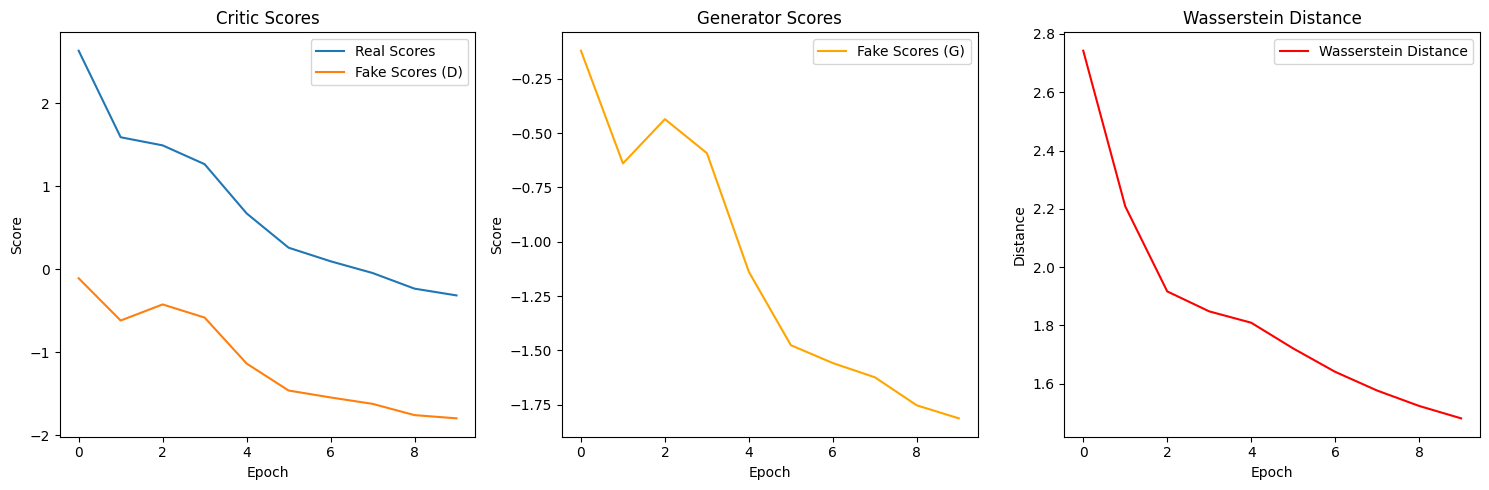

In [24]:
epochs = range(config.num_epochs)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, REAL_SCORES, label='Real Scores')
plt.plot(epochs, FAKE_SCORES_D, label='Fake Scores (D)')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Critic Scores')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, FAKE_SCORES_G, label='Fake Scores (G)', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Generator Scores')
plt.legend()

plt.subplot(1, 3, 3)
wasserstein_dist = REAL_SCORES - FAKE_SCORES_D
plt.plot(epochs, wasserstein_dist, label='Wasserstein Distance', color='red')
plt.xlabel('Epoch')
plt.ylabel('Distance')
plt.title('Wasserstein Distance')
plt.legend()

plt.tight_layout()
plt.show()

Как видим для gradient_penalty результаты оказались сильно хуже чем с обычным weight_cliping, могу предположить, что это связано с простотой данных и для простых данных лучше использовать 2-й метод

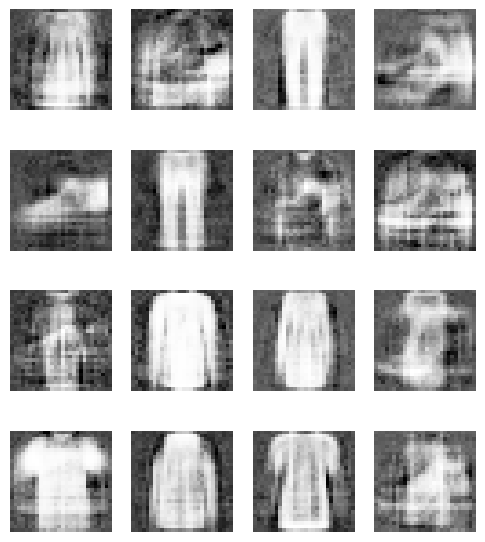

In [25]:
noise = torch.randn(batch_size, config.noise_size, device=device)
fake = generator(noise)

plt.figure(figsize=(6, 7))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake[i].detach().cpu().numpy().reshape(
        28, 28), cmap=plt.cm.Greys_r)
    plt.axis('off')

In [26]:
class ConditionalGenerator(nn.Module):
    def __init__(self, noise_size=50, num_classes=10, hidden_size=100, output_size=784):
        super().__init__()
        self.noise_size = noise_size
        self.num_classes = num_classes

        self.model = nn.Sequential(
            nn.Linear(noise_size + num_classes, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_size, output_size),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        one_hot = torch.zeros(labels.size(
            0), self.num_classes, device=noise.device)
        one_hot.scatter_(1, labels.unsqueeze(1), 1)

        conditioned_input = torch.cat([noise, one_hot], dim=1)

        return self.model(conditioned_input)

In [27]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, input_size=784, num_classes=10, hidden_size=128):
        super().__init__()
        self.input_size = input_size
        self.num_classes = num_classes

        self.model = nn.Sequential(
            nn.Linear(input_size + num_classes, hidden_size),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x, labels):
        one_hot = torch.zeros(labels.size(
            0), self.num_classes, device=x.device)
        one_hot.scatter_(1, labels.unsqueeze(1), 1)

        conditioned_input = torch.cat([x, one_hot], dim=1)

        return self.model(conditioned_input)

In [29]:
generator = ConditionalGenerator().to(device)
discriminator = ConditionalDiscriminator().to(device)

criterion = nn.BCELoss()
optim_D = optim.Adam(params=discriminator.parameters(), lr=0.0001)
optim_G = optim.Adam(params=generator.parameters(), lr=0.0001)

noise = torch.FloatTensor(config.batch_size, config.noise_size).to(device)
label = torch.FloatTensor(config.batch_size, 1).to(device)
real_label = 1
fake_label = 0

ERRD_x = np.zeros(config.num_epochs)
ERRD_z = np.zeros(config.num_epochs)
ERRG = np.zeros(config.num_epochs)
N = len(dataloader)

for epoch in range(config.num_epochs):
    for iteration, (images, labels) in enumerate(dataloader):
        batch_size = images.size(0)
        images = images.to(device)
        labels = labels.to(device)

        discriminator.zero_grad()

        label.fill_(real_label)
        input_data = images.view(batch_size, -1)
        output = discriminator(input_data, labels)
        errD_x = criterion(output, label)
        ERRD_x[epoch] += errD_x.item()
        errD_x.backward()

        noise.normal_(0, 1)
        fake_labels = torch.randint(
            0, 10, (batch_size,), device=device)
        fake = generator(noise, fake_labels)
        label.fill_(fake_label)
        output = discriminator(fake.detach(), fake_labels)
        errD_z = criterion(output, label)
        ERRD_z[epoch] += errD_z.item()
        errD_z.backward()

        optim_D.step()

        generator.zero_grad()
        label.fill_(real_label)
        output = discriminator(fake, fake_labels)
        errG = criterion(output, label)
        ERRG[epoch] += errG.item()
        errG.backward()

        optim_G.step()

        if (iteration+1) % config.print_freq == 0:
            print('Epoch:{} Iter: {} errD_x: {:.4f} errD_z: {:.4f} errG: {:.4f}'.format(
                epoch+1, iteration+1, errD_x.item(), errD_z.item(), errG.item()))

ERRD_x /= N
ERRD_z /= N
ERRG /= N

Epoch:1 Iter: 100 errD_x: 0.2724 errD_z: 0.6938 errG: 0.7467
Epoch:1 Iter: 200 errD_x: 0.3151 errD_z: 0.6284 errG: 0.8640
Epoch:1 Iter: 300 errD_x: 0.3807 errD_z: 0.3607 errG: 1.4088
Epoch:1 Iter: 400 errD_x: 0.2232 errD_z: 0.2478 errG: 1.7539
Epoch:1 Iter: 500 errD_x: 0.4829 errD_z: 0.4469 errG: 1.2652
Epoch:1 Iter: 600 errD_x: 0.5402 errD_z: 0.5961 errG: 1.0691
Epoch:1 Iter: 700 errD_x: 0.3467 errD_z: 0.2572 errG: 1.7850
Epoch:1 Iter: 800 errD_x: 0.3964 errD_z: 0.2703 errG: 1.7361
Epoch:1 Iter: 900 errD_x: 0.2250 errD_z: 0.1882 errG: 2.1866
Epoch:1 Iter: 1000 errD_x: 0.2491 errD_z: 0.1202 errG: 2.5163
Epoch:1 Iter: 1100 errD_x: 0.2020 errD_z: 0.1472 errG: 2.2642
Epoch:1 Iter: 1200 errD_x: 0.3060 errD_z: 0.1584 errG: 2.5200
Epoch:1 Iter: 1300 errD_x: 0.1719 errD_z: 0.1617 errG: 2.6769
Epoch:1 Iter: 1400 errD_x: 0.1022 errD_z: 0.1499 errG: 2.7725
Epoch:1 Iter: 1500 errD_x: 0.0889 errD_z: 0.1206 errG: 2.7942
Epoch:1 Iter: 1600 errD_x: 0.1622 errD_z: 0.2033 errG: 2.5548
Epoch:1 Iter: 170

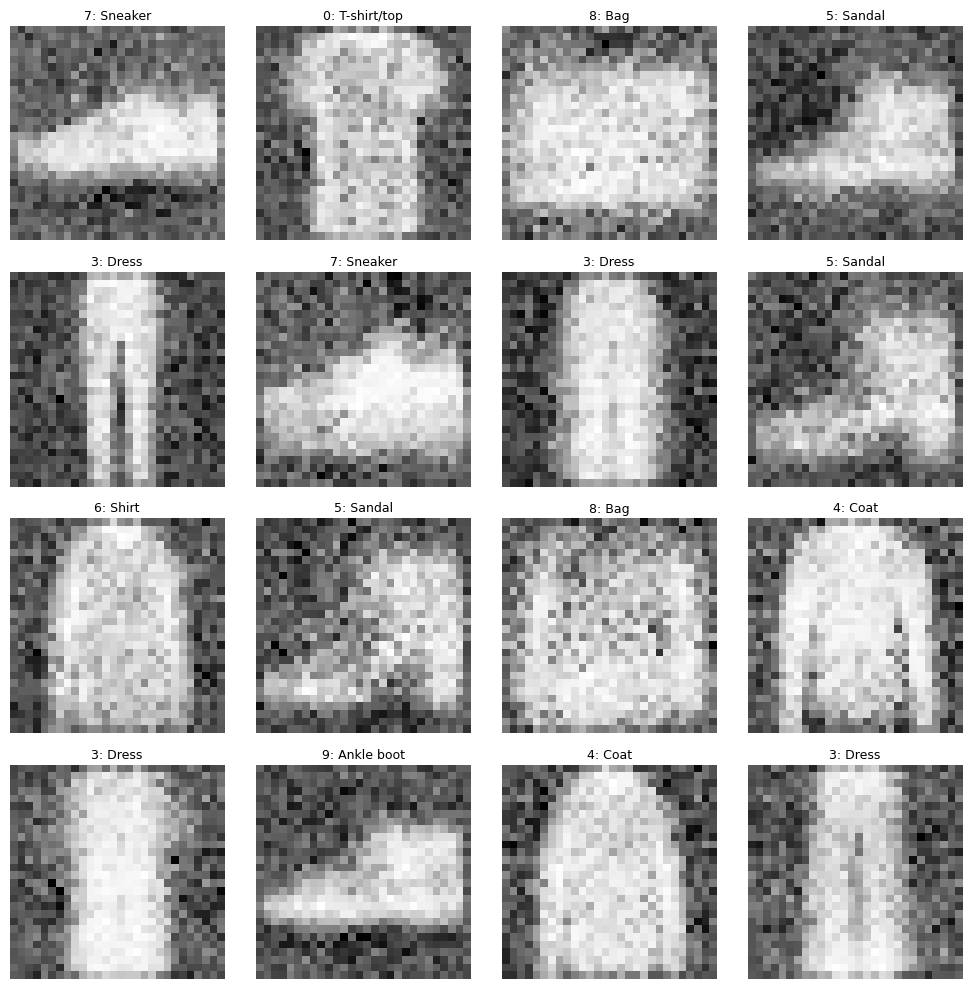

In [ ]:
fashion_mnist_classes = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

noise = torch.randn(batch_size, config.noise_size, device=device)
fake_labels = torch.randint(0, 10, (batch_size,), device=device)
fake = generator(noise, fake_labels)

plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake[i].detach().cpu().numpy().reshape(
        28, 28), cmap=plt.cm.Greys_r)

    class_id = fake_labels[i].item()
    class_name = fashion_mnist_classes[class_id]

    plt.title(f'{class_id}: {class_name}', fontsize=9, pad=5)
    plt.axis('off')

plt.tight_layout()
plt.show()

Видно что обычный ган обучился не очень, но метки из меток семплирует картинку хорошо